# Section 5 — Simulation Study

This notebook generates the controlled simulation results reported in Section 5 of the paper.

The purpose is **mechanism verification**, not Monte Carlo performance comparison. Each experiment uses one fixed simulated realization and summarizes variation across target locations within that realization.

The four checks correspond directly to the four substantive subsections of Section 5:

- **5.2 Isotropy sanity check**
- **5.3 Geometric anisotropy activation**
- **5.4 ESS safeguard under stress**
- **5.5 Value-based calibration activation**

All GR fits are executed through the installed `gimbal-regression` package. The estimator itself is not reimplemented inside this notebook.


## Reproducibility environment

The manuscript replication target is `gimbal-regression==0.1.6`.  
Results should be regenerated top-to-bottom in the same environment used for the final paper.


In [1]:
from importlib.metadata import version
import os
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import grpy
from grpy import GimbalRegression

GR_VERSION = version("gimbal-regression")

print("gimbal-regression:", GR_VERSION)
print("grpy.__version__:", grpy.__version__)
print("Python platform:", platform.platform())
print("Machine:", platform.machine())

assert GR_VERSION == "0.1.6"
assert grpy.__version__ == "0.1.6"

OUTPUT_DIR = "section5_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def display_3(df, *, integer_columns=()):
    fmt = {}
    for col in df.columns:
        if col in integer_columns:
            fmt[col] = "{:.0f}"
        elif pd.api.types.is_numeric_dtype(df[col]):
            fmt[col] = "{:.3f}"
    display(df.style.format(fmt))


gimbal-regression: 0.1.6
grpy.__version__: 0.1.6
Python platform: Linux-6.8.0-106-generic-x86_64-with-glibc2.39
Machine: x86_64


## 5.1 Simulation design

Locations are generated in a local East--North coordinate plane and converted to latitude/longitude around the fixed reference point \(35^\circ\mathrm{N},135^\circ\mathrm{E}\).

Unless a subsection states otherwise:

- \(N=1200\)
- \(K=50\)
- \(h=3000\) m
- \(\gamma=1\)
- \(n_0=15\)
- \(n_{\min}=4\)
- \(\varepsilon_\phi=10^{-3}\)
- \(\varepsilon_\theta=10^{-8}\)
- \(\varepsilon_\eta=10^{-8}\)
- \(\eta_{\max}=50\)

The baseline response is generated from one scalar covariate with a spatially varying coefficient plus Gaussian noise. Geometric anisotropy is introduced by a rotate--stretch--rotate-back transformation. The value-calibration experiment replaces coefficient heterogeneity with an explicit normalized radial response component.

Seeds are fixed by experiment: 1, 2, 3, and 4.


In [2]:
EARTH_R = 6_371_000.0
LAT0_DEG = 35.0
LON0_DEG = 135.0
EXTENT_ISO = (80_000.0, 80_000.0)
SIGMA_GAUSS = (20_000.0, 20_000.0)


def _local_xy_uniform(
    N,
    seed=0,
    *,
    extent_m=(60_000.0, 60_000.0),
    center_xy_m=(0.0, 0.0),
):
    rng = np.random.default_rng(seed)
    Lx, Ly = map(float, extent_m)
    cx, cy = map(float, center_xy_m)

    x = rng.uniform(cx - Lx / 2.0, cx + Lx / 2.0, size=N)
    y = rng.uniform(cy - Ly / 2.0, cy + Ly / 2.0, size=N)
    return x, y


def _local_xy_gaussian(
    N,
    seed=0,
    *,
    sigma_m=(15_000.0, 15_000.0),
    center_xy_m=(0.0, 0.0),
):
    rng = np.random.default_rng(seed)
    sx, sy = map(float, sigma_m)
    cx, cy = map(float, center_xy_m)

    x = cx + rng.normal(scale=sx, size=N)
    y = cy + rng.normal(scale=sy, size=N)
    return x, y


def local_xy_to_latlon(
    x_east_m,
    y_north_m,
    *,
    lat0_deg=LAT0_DEG,
    lon0_deg=LON0_DEG,
):
    lat0 = np.deg2rad(float(lat0_deg))
    lon0 = np.deg2rad(float(lon0_deg))

    dlat = np.asarray(y_north_m, dtype=float) / EARTH_R
    dlon = np.asarray(x_east_m, dtype=float) / (EARTH_R * np.cos(lat0))

    lat = lat0 + dlat
    lon = lon0 + dlon

    return np.rad2deg(lat), np.rad2deg(lon)


def apply_anisotropic_stretch_xy(
    x_m,
    y_m,
    *,
    stretch=5.0,
    rot=np.pi / 4,
):
    x = np.asarray(x_m, dtype=float).copy()
    y = np.asarray(y_m, dtype=float).copy()

    x_mean = float(x.mean())
    y_mean = float(y.mean())

    x -= x_mean
    y -= y_mean

    c = np.cos(rot)
    s = np.sin(rot)

    xr = c * x - s * y
    yr = s * x + c * y

    xr *= float(stretch)

    x2 = c * xr + s * yr
    y2 = -s * xr + c * yr

    x2 += x_mean
    y2 += y_mean

    return x2, y2


def radial_distance_m(x_m, y_m):
    x = np.asarray(x_m, dtype=float) - float(np.mean(x_m))
    y = np.asarray(y_m, dtype=float) - float(np.mean(y_m))
    return np.sqrt(x * x + y * y)


def make_dataset(
    N=1200,
    seed=0,
    *,
    lat0_deg=LAT0_DEG,
    lon0_deg=LON0_DEG,
    coord_mode="uniform",
    extent_m=(60_000.0, 60_000.0),
    sigma_m=(15_000.0, 15_000.0),
    center_xy_m=(0.0, 0.0),
    stretch=None,
    rot=np.pi / 4,
    x_dist="normal",
    hetero=1.0,
    beta_surface="lat_linear",
    noise=1.0,
    radial_trend=0.0,
    x_radial_interaction=0.0,
):
    if coord_mode == "uniform":
        x_m, y_m = _local_xy_uniform(
            N,
            seed=seed,
            extent_m=extent_m,
            center_xy_m=center_xy_m,
        )
    elif coord_mode == "gaussian":
        x_m, y_m = _local_xy_gaussian(
            N,
            seed=seed,
            sigma_m=sigma_m,
            center_xy_m=center_xy_m,
        )
    else:
        raise ValueError("coord_mode must be 'uniform' or 'gaussian'.")

    if stretch is not None:
        x_m, y_m = apply_anisotropic_stretch_xy(
            x_m,
            y_m,
            stretch=stretch,
            rot=rot,
        )

    lat, lon = local_xy_to_latlon(
        x_m,
        y_m,
        lat0_deg=lat0_deg,
        lon0_deg=lon0_deg,
    )

    rng = np.random.default_rng(seed + 10)

    if x_dist == "normal":
        X = rng.normal(size=N)
    elif x_dist == "uniform":
        X = rng.uniform(-1.0, 1.0, size=N)
    else:
        raise ValueError("x_dist must be 'normal' or 'uniform'.")

    if beta_surface == "lat_linear":
        denom = lat.max() - lat.min() + 1e-12
        beta1 = 1.0 + float(hetero) * (lat - lat.mean()) / denom
    elif beta_surface == "x_linear":
        denom = x_m.max() - x_m.min() + 1e-12
        beta1 = 1.0 + float(hetero) * (x_m - x_m.mean()) / denom
    elif beta_surface == "none":
        beta1 = np.ones(N, dtype=float)
    else:
        raise ValueError(
            "beta_surface must be 'lat_linear', 'x_linear', or 'none'."
        )

    r_m = radial_distance_m(x_m, y_m)
    r_norm = r_m / (float(np.mean(r_m)) + 1e-12)

    eps = rng.normal(scale=float(noise), size=N)

    Y = (
        beta1 * X
        + float(radial_trend) * r_norm
        + eps
    )

    if x_radial_interaction != 0.0:
        Y = Y + float(x_radial_interaction) * X * r_norm

    return pd.DataFrame({
        "lat": lat,
        "lon": lon,
        "X": X,
        "Y": Y,
        "x_m": x_m,
        "y_m": y_m,
        "r_m": r_m,
        "beta1": beta1,
    })


### GR variants and summary helpers

Three diagnostic variants are used where needed:

- `full`: complete GR.
- `theta_z_off`: value-based calibration is disabled.
- `isotropic_proxy`: both orientation components are disabled and `eta=1`.

These variants share the same coefficient solve and differ only in the directional-weight construction.


In [3]:
def fit_gr_variant(
    df,
    *,
    variant="full",
    K=50,
    h_m=3000.0,
    gamma=1.0,
    n0=15.0,
    min_neff=4.0,
    use_ess=True,
    eps_phi=1e-3,
    eps_theta=1e-8,
    eps_eta=1e-8,
    eta_max=50.0,
    u_scale=None,
):
    params = dict(
        K=K,
        h_m=h_m,
        gamma=gamma,
        n0=n0,
        min_neff=min_neff,
        use_ess=use_ess,
        eps_phi=eps_phi,
        eps_theta=eps_theta,
        eps_eta=eps_eta,
        eta_max=eta_max,
        u_scale=(h_m if u_scale is None else u_scale),
        compute_local_moran=False,
    )

    if variant == "full":
        pass
    elif variant == "theta_z_off":
        params["eps_theta"] = 1e9
    elif variant == "isotropic_proxy":
        params["eps_phi"] = 1e9
        params["eps_theta"] = 1e9
        params["eta_max"] = 1.0
    else:
        raise ValueError(
            "variant must be 'full', 'theta_z_off', or 'isotropic_proxy'."
        )

    model = GimbalRegression(**params).fit(
        y=df["Y"].to_numpy(dtype=float),
        x=df["X"].to_numpy(dtype=float),
        lat=df["lat"].to_numpy(dtype=float),
        lon=df["lon"].to_numpy(dtype=float),
    )

    res = model.results_.copy()

    if model.n_errors_:
        raise RuntimeError(
            f"{variant}: {model.n_errors_} local fits failed."
        )

    return res


def _numeric(res, col):
    return pd.to_numeric(res[col], errors="coerce")


def summarize_results(res, K):
    out = {"N": len(res)}

    for col in [
        "RMSE",
        "R2",
        "AdjR2",
        "condM_nor",
        "neff_raw",
        "neff_post",
        "eta",
        "r_phi",
        "g_ident",
        "alpha",
        "theta_z",
    ]:
        if col not in res.columns:
            continue

        v = _numeric(res, col)
        out[f"{col}_mean"] = float(v.mean())
        out[f"{col}_std"] = float(v.std(ddof=0))

        if col == "condM_nor":
            out["condM_nor_median"] = float(v.median())
            out["condM_nor_p95"] = float(v.quantile(0.95))
            out["condM_nor_p99"] = float(v.quantile(0.99))

    if "phi" in res.columns:
        out["phi_zero_rate"] = float(
            (_numeric(res, "phi").abs() < 1e-15).mean()
        )

    if "theta_z" in res.columns:
        out["theta_zero_rate"] = float(
            (_numeric(res, "theta_z").abs() < 1e-15).mean()
        )

    if "uniform_flag" in res.columns:
        out["uniform_rate"] = float(
            _numeric(res, "uniform_flag").mean()
        )
        out["uniform_count"] = int(
            _numeric(res, "uniform_flag").sum()
        )

    if "neff_post" in res.columns:
        out["neff_post_minus_K_mean"] = float(
            _numeric(res, "neff_post").mean() - K
        )

    return pd.Series(out)


def summarize_weight_difference(res_a, res_b, *, name="A_vs_B"):
    l1 = []
    cor = []

    for wa, wb in zip(res_a["w_gr"], res_b["w_gr"]):
        wa = np.asarray(wa, dtype=float)
        wb = np.asarray(wb, dtype=float)

        if wa.shape != wb.shape or wa.size == 0:
            continue

        l1.append(float(np.sum(np.abs(wa - wb))))

        if np.std(wa) > 1e-12 and np.std(wb) > 1e-12:
            cor.append(float(np.corrcoef(wa, wb)[0, 1]))

    return pd.Series({
        "pair": name,
        "w_L1_mean": float(np.mean(l1)) if l1 else np.nan,
        "w_L1_std": float(np.std(l1, ddof=0)) if l1 else np.nan,
        "w_corr_mean": float(np.mean(cor)) if cor else np.nan,
        "w_corr_std": float(np.std(cor, ddof=0)) if cor else np.nan,
    })


def compact_summary_table(results_by_name):
    rows = []

    for name, (res, K) in results_by_name.items():
        s = summarize_results(res, K)

        rows.append({
            "Variant": name,
            "RMSE": s.get("RMSE_mean", np.nan),
            "R2": s.get("R2_mean", np.nan),
            "CondMean": s.get("condM_nor_mean", np.nan),
            "ESS_raw": s.get("neff_raw_mean", np.nan),
            "ESS_post": s.get("neff_post_mean", np.nan),
            "Eta": s.get("eta_mean", np.nan),
            "phi_zero_rate": s.get("phi_zero_rate", np.nan),
            "theta_zero_rate": s.get("theta_zero_rate", np.nan),
            "uniform_rate": s.get("uniform_rate", np.nan),
        })

    return pd.DataFrame(rows)


## 5.2 Isotropy sanity check

**Question.** Does GR remain close to an isotropic local estimator when no geometric anisotropy is imposed?

Design:

- seed = 1
- uniform \(80\,\mathrm{km}\times80\,\mathrm{km}\) domain
- no geometric stretch
- baseline spatially varying coefficient surface
- \(K=50\), \(h=3000\) m, \(n_0=15\), \(n_{\min}=4\)

The comparison is restricted to the three variants reported in Table 2.


In [4]:
df52 = make_dataset(
    N=1200,
    seed=1,
    coord_mode="uniform",
    extent_m=EXTENT_ISO,
    stretch=None,
    rot=np.pi / 4,
    x_dist="normal",
    hetero=1.0,
    beta_surface="lat_linear",
    noise=1.0,
    radial_trend=0.0,
)

settings52 = dict(
    K=50,
    h_m=3000.0,
    gamma=1.0,
    n0=15.0,
    min_neff=4.0,
    use_ess=True,
    eps_phi=1e-3,
    eps_theta=1e-8,
    eps_eta=1e-8,
    eta_max=50.0,
)

res52_full = fit_gr_variant(df52, variant="full", **settings52)
res52_theta_off = fit_gr_variant(df52, variant="theta_z_off", **settings52)
res52_iso = fit_gr_variant(df52, variant="isotropic_proxy", **settings52)

table2 = compact_summary_table({
    "Isotropic proxy": (res52_iso, 50),
    "GR (theta_z OFF)": (res52_theta_off, 50),
    "GR (full)": (res52_full, 50),
})[
    [
        "Variant", "RMSE", "R2", "CondMean",
        "ESS_raw", "ESS_post", "Eta",
        "phi_zero_rate", "theta_zero_rate", "uniform_rate"
    ]
]

display_3(table2)
table2.to_csv(
    os.path.join(OUTPUT_DIR, "table2_isotropy.csv"),
    index=False,
    float_format="%.6f",
)


,Variant,RMSE,R2,CondMean,ESS_raw,ESS_post,Eta,phi_zero_rate,theta_zero_rate,uniform_rate
0,Isotropic proxy,0.960,0.493,51.235,10.565,15.224,1.000,1.000,1.000,0.000
1,GR (theta_z OFF),0.960,0.493,51.247,12.883,15.201,1.263,0.000,1.000,0.000
2,GR (full),0.960,0.493,51.257,12.900,15.206,1.263,0.000,0.000,0.000


**Table 2 reading.** Prediction and conditioning are essentially unchanged across the three variants at the reported precision, while the internal directional diagnostics distinguish the full estimator from the isotropic proxy.


## 5.3 Geometric anisotropy activation

**Question.** Does the geometry-based component alter the directional weight field under an elongated spatial configuration?

Design:

- seed = 2
- uniform \(80\,\mathrm{km}\times80\,\mathrm{km}\) base domain
- stretch factor \(\rho=10\)
- rotation \(\psi=\pi/4\)
- \(K=50\), \(h=3000\) m, \(n_0=15\), \(n_{\min}=4\)

Table 3 summarizes estimator diagnostics. Table 4 compares the realized directional weight vectors directly.


In [5]:
df53 = make_dataset(
    N=1200,
    seed=2,
    coord_mode="uniform",
    extent_m=EXTENT_ISO,
    stretch=10.0,
    rot=np.pi / 4,
    x_dist="normal",
    hetero=1.0,
    beta_surface="lat_linear",
    noise=1.0,
    radial_trend=0.0,
)

settings53 = dict(
    K=50,
    h_m=3000.0,
    gamma=1.0,
    n0=15.0,
    min_neff=4.0,
    use_ess=True,
    eps_phi=1e-3,
    eps_theta=1e-8,
    eps_eta=1e-8,
    eta_max=50.0,
)

res53_iso = fit_gr_variant(df53, variant="isotropic_proxy", **settings53)
res53_gr = fit_gr_variant(df53, variant="full", **settings53)

table3 = compact_summary_table({
    "Isotropic proxy": (res53_iso, 50),
    "GR": (res53_gr, 50),
})[
    [
        "Variant", "RMSE", "R2", "CondMean",
        "ESS_raw", "ESS_post", "Eta",
        "phi_zero_rate", "theta_zero_rate", "uniform_rate"
    ]
]

wd53 = summarize_weight_difference(
    res53_gr,
    res53_iso,
    name="GR vs isotropic proxy",
)

table4 = pd.DataFrame({
    "Quantity": [
        "Mean L1 weight difference",
        "Mean weight correlation",
    ],
    "Value": [
        wd53["w_L1_mean"],
        wd53["w_corr_mean"],
    ],
})

print("Table 3")
display_3(table3)

print("Table 4")
display_3(table4)

table3.to_csv(
    os.path.join(OUTPUT_DIR, "table3_geometry.csv"),
    index=False,
    float_format="%.6f",
)
table4.to_csv(
    os.path.join(OUTPUT_DIR, "table4_geometry_weight_difference.csv"),
    index=False,
    float_format="%.6f",
)


Table 3


,Variant,RMSE,R2,CondMean,ESS_raw,ESS_post,Eta,phi_zero_rate,theta_zero_rate,uniform_rate
0,Isotropic proxy,0.965,0.499,449.954,1.873,9.281,1.000,1.000,1.000,0.018
1,GR,0.965,0.499,460.314,3.542,10.885,4.962,0.000,0.000,0.007


Table 4


,Quantity,Value
0,Mean L1 weight difference,0.502
1,Mean weight correlation,0.876


**Tables 3--4 reading.** The elongated geometry activates \(\eta_i\) and changes the realized local weight vectors, while predictive summaries remain essentially unchanged in this controlled realization.


## 5.4 ESS safeguard under stress

**Question.** Does the one-shot ESS correction respond systematically to its target \(n_0\)?

Design:

- seed = 3
- Gaussian spatial point cloud
- 20 km standard deviation on each undeformed local axis
- stretch factor \(\rho=10\), rotation \(\psi=\pi/4\)
- \(K=30\), \(h=2000\) m
- \(n_{\min}=12\)
- \(n_0\in\{6,8,10,15,20,30,50,75,100\}\)

The same simulated dataset is reused for every \(n_0\); only the safeguard target changes.


In [6]:
df54 = make_dataset(
    N=1200,
    seed=3,
    coord_mode="gaussian",
    sigma_m=SIGMA_GAUSS,
    stretch=10.0,
    rot=np.pi / 4,
    x_dist="normal",
    hetero=1.0,
    beta_surface="lat_linear",
    noise=1.0,
    radial_trend=0.0,
)

n0_grid = [6, 8, 10, 15, 20, 30, 50, 75, 100]

res54_by_n0 = {}
rows54 = []

for n0 in n0_grid:
    res = fit_gr_variant(
        df54,
        variant="full",
        K=30,
        h_m=2000.0,
        gamma=1.0,
        n0=float(n0),
        min_neff=12.0,
        use_ess=True,
        eps_phi=1e-3,
        eps_theta=1e-8,
        eps_eta=1e-8,
        eta_max=50.0,
    )

    res54_by_n0[float(n0)] = res
    s = summarize_results(res, 30)

    rows54.append({
        "n0": float(n0),
        "ESS_raw": s.get("neff_raw_mean", np.nan),
        "ESS_post": s.get("neff_post_mean", np.nan),
        "CondMean": s.get("condM_nor_mean", np.nan),
        "RMSE": s.get("RMSE_mean", np.nan),
        "R2": s.get("R2_mean", np.nan),
        "uniform_rate": s.get("uniform_rate", np.nan),
    })

table5 = pd.DataFrame(rows54)

display_3(table5, integer_columns=("n0",))
table5.to_csv(
    os.path.join(OUTPUT_DIR, "table5_ess_safeguard.csv"),
    index=False,
    float_format="%.6f",
)


,n0,ESS_raw,ESS_post,CondMean,RMSE,R2,uniform_rate
0,6,3.229,4.963,989.309,0.936,0.511,0.999
1,8,3.229,5.993,989.109,0.936,0.511,0.993
2,10,3.229,6.906,988.332,0.936,0.511,0.971
3,15,3.229,8.850,984.298,0.936,0.511,0.843
4,20,3.229,10.464,980.555,0.936,0.511,0.693
5,30,3.229,13.041,973.285,0.936,0.511,0.432
6,50,3.229,16.610,964.851,0.936,0.511,0.195
7,75,3.229,19.458,961.643,0.936,0.511,0.100
8,100,3.229,21.362,960.793,0.936,0.511,0.069


### Figure candidates for Section 5

Only the ESS experiment produces response curves that add information beyond the tables. The two figures below are therefore retained as manuscript candidates. Other exploratory maps and histograms are omitted from this clean notebook.


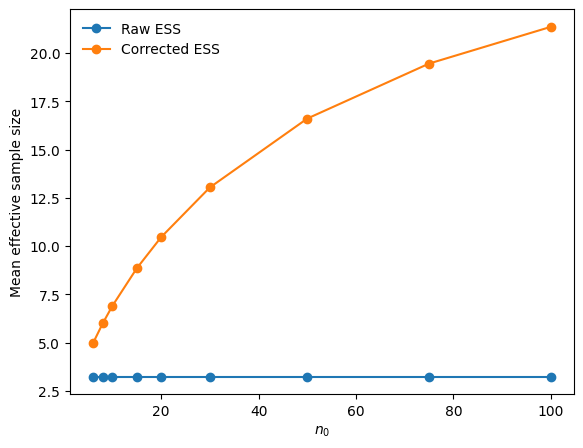

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 5.0))

ax.plot(
    table5["n0"],
    table5["ESS_raw"],
    marker="o",
    label="Raw ESS",
)
ax.plot(
    table5["n0"],
    table5["ESS_post"],
    marker="o",
    label="Corrected ESS",
)

ax.set_xlabel(r"$n_0$")
ax.set_ylabel("Mean effective sample size")
ax.legend(frameon=False)

fig.savefig(
    os.path.join(OUTPUT_DIR, "figure_ess_response.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()


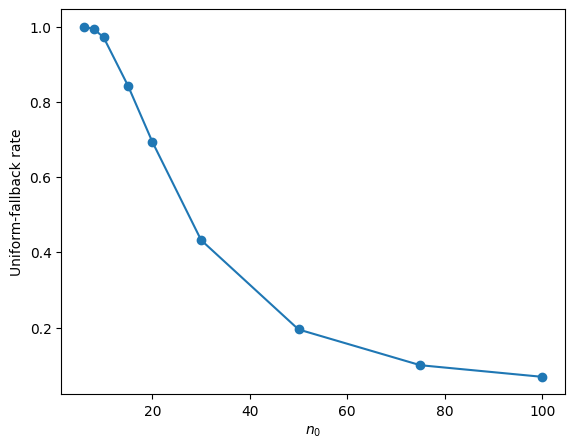

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 5.0))

ax.plot(
    table5["n0"],
    table5["uniform_rate"],
    marker="o",
)

ax.set_xlabel(r"$n_0$")
ax.set_ylabel("Uniform-fallback rate")

fig.savefig(
    os.path.join(OUTPUT_DIR, "figure_uniform_fallback.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()


**Table 5 and figure reading.** Raw ESS is fixed because the underlying realization does not change. Increasing \(n_0\) raises corrected pre-fallback ESS and reduces the frequency of uniform fallback. This is a safeguard-response check, not evidence that ESS determines local rank or conditioning.


## 5.5 Value-based calibration activation

**Question.** Does the value-based calibration change realized weights when the response contains a deliberately introduced distance-linked component?

Design:

- seed = 4
- uniform \(80\,\mathrm{km}\times80\,\mathrm{km}\) domain
- no geometric deformation (\(\rho=1\))
- no spatial coefficient heterogeneity
- normalized radial response term \(c_{\mathrm{rad}}=8\)
- \(K=30\), \(h=2000\) m, \(n_0=20\), \(n_{\min}=4\)

Removing geometric deformation isolates the value-based calibration mechanism from the geometric-anisotropy mechanism examined in Section 5.3.


In [9]:
df55 = make_dataset(
    N=1200,
    seed=4,
    coord_mode="uniform",
    extent_m=EXTENT_ISO,
    stretch=None,
    rot=np.pi / 4,
    x_dist="normal",
    hetero=0.0,
    beta_surface="none",
    noise=1.0,
    radial_trend=8.0,
)

settings55 = dict(
    K=30,
    h_m=2000.0,
    gamma=1.0,
    n0=20.0,
    min_neff=4.0,
    use_ess=True,
    eps_phi=1e-3,
    eps_theta=1e-8,
    eps_eta=1e-8,
    eta_max=50.0,
)

res55_on = fit_gr_variant(df55, variant="full", **settings55)
res55_off = fit_gr_variant(df55, variant="theta_z_off", **settings55)

s55_on = summarize_results(res55_on, 30)
s55_off = summarize_results(res55_off, 30)

table6 = pd.DataFrame([
    {
        "Variant": "GR (theta_z OFF)",
        "theta_mean": s55_off.get("theta_z_mean", np.nan),
        "theta_SD": s55_off.get("theta_z_std", np.nan),
        "theta_zero_rate": s55_off.get("theta_zero_rate", np.nan),
        "CondMean": s55_off.get("condM_nor_mean", np.nan),
        "ESS_raw": s55_off.get("neff_raw_mean", np.nan),
        "ESS_post": s55_off.get("neff_post_mean", np.nan),
        "Eta": s55_off.get("eta_mean", np.nan),
        "RMSE": s55_off.get("RMSE_mean", np.nan),
        "R2": s55_off.get("R2_mean", np.nan),
        "uniform_rate": s55_off.get("uniform_rate", np.nan),
    },
    {
        "Variant": "GR (theta_z ON)",
        "theta_mean": s55_on.get("theta_z_mean", np.nan),
        "theta_SD": s55_on.get("theta_z_std", np.nan),
        "theta_zero_rate": s55_on.get("theta_zero_rate", np.nan),
        "CondMean": s55_on.get("condM_nor_mean", np.nan),
        "ESS_raw": s55_on.get("neff_raw_mean", np.nan),
        "ESS_post": s55_on.get("neff_post_mean", np.nan),
        "Eta": s55_on.get("eta_mean", np.nan),
        "RMSE": s55_on.get("RMSE_mean", np.nan),
        "R2": s55_on.get("R2_mean", np.nan),
        "uniform_rate": s55_on.get("uniform_rate", np.nan),
    },
])

wd55 = summarize_weight_difference(
    res55_on,
    res55_off,
    name="theta_z ON vs OFF",
)

table7 = pd.DataFrame({
    "Quantity": [
        "Mean L1 weight difference",
        "Mean weight correlation",
    ],
    "Value": [
        wd55["w_L1_mean"],
        wd55["w_corr_mean"],
    ],
})

print("Table 6")
display_3(table6)

print("Table 7")
display_3(table7)

table6.to_csv(
    os.path.join(OUTPUT_DIR, "table6_value_calibration.csv"),
    index=False,
    float_format="%.6f",
)
table7.to_csv(
    os.path.join(OUTPUT_DIR, "table7_value_weight_difference.csv"),
    index=False,
    float_format="%.6f",
)


Table 6


,Variant,theta_mean,theta_SD,theta_zero_rate,CondMean,ESS_raw,ESS_post,Eta,RMSE,R2,uniform_rate
0,GR (theta_z OFF),0.000,0.000,1.000,61.565,6.769,17.235,1.445,1.268,0.367,0.000
1,GR (theta_z ON),0.795,0.319,0.000,61.585,6.770,17.238,1.445,1.268,0.367,0.000


Table 7


,Quantity,Value
0,Mean L1 weight difference,0.236
1,Mean weight correlation,0.926


**Tables 6--7 reading.** Enabling value-based calibration produces nonzero \(\theta_{z,i}^{*}\) and a measurable change in realized directional weights, while prediction, conditioning, and corrected ESS remain essentially unchanged in this constructed regime.


## Section 5 output files

A top-to-bottom run writes the manuscript-facing numerical outputs to `section5_outputs/`:

- `table2_isotropy.csv`
- `table3_geometry.csv`
- `table4_geometry_weight_difference.csv`
- `table5_ess_safeguard.csv`
- `table6_value_calibration.csv`
- `table7_value_weight_difference.csv`
- `figure_ess_response.png`
- `figure_uniform_fallback.png`

The CSV files retain six decimal places for reproducibility. Notebook displays use three decimal places to match the manuscript.


## Reproducibility scope

These simulations are intentionally single-realization, fixed-seed mechanism checks. Means and rates summarize the \(N=1200\) target locations within each controlled realization; they are not Monte Carlo expectations or repeated-sample uncertainty estimates.

The notebook is therefore aligned with the stated scope of Section 5: verifying that the realized components of GR respond consistently with their definitions.
